# EMNIST Character Classification using HOG + SVM + LOOCV

| | |
|---|---|
| **Nama** | Pandu Hariandika Pratama |
| **NIM** | 4222301076 |
| **Dataset** | EMNIST Letters (26 kelas, A–Z) |
| **Metode** | HOG + SVM + LOOCV |

---
## 1. Install Library

In [1]:
!pip install matplotlib numpy seaborn scikit-learn scikit-image mlxtend -q

---
## 2. Import Library

In [25]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import pandas as pd
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.model_selection import (
    LeaveOneOut, GridSearchCV, cross_val_predict, train_test_split
)
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score
)

np.random.seed(42)
print('✅ Semua library berhasil diimport!')

✅ Semua library berhasil diimport!


---
## 3. Dataset Preparation

Dataset yang digunakan adalah **EMNIST Letters** dengan ketentuan:
- Total **2600 sampel** (100 sampel × 26 kelas)
- Setiap gambar berukuran **28×28 pixel** (784 nilai)
- Dataset di-**shuffle** sebelum diambil sampelnya agar distribusi acak

In [26]:
# ── Load Dataset ────────────────────────────────────────────────
CSV_PATH = 'emist/emnist-letters-train.csv'

print('Loading dataset...')
data = pd.read_csv(CSV_PATH, header=None)

data_labels = data.iloc[:, 0].values
data_img    = data.iloc[:, 1:].values

print(f'Total images tersedia : {len(data_img)}')
print(f'Ukuran setiap gambar  : {data_img.shape[1]} pixel (28x28)')

Loading dataset...
Total images tersedia : 88800
Ukuran setiap gambar  : 784 pixel (28x28)


In [27]:
# ── Preprocessing: Label + Shuffle + Sampling ───────────────────

# Label EMNIST: 1=A ... 26=Z → ubah ke 0-based (0=A ... 25=Z)
data_labels = data_labels - 1

# Shuffle dataset sebelum sampling
shuffle_idx = np.random.permutation(len(data_img))
data_img    = data_img[shuffle_idx]
data_labels = data_labels[shuffle_idx]

# Ambil 100 sampel per kelas (balanced)
SAMPLES_PER_CLASS = 100
NUM_CLASSES       = 26

selected_img    = []
selected_labels = []

for class_idx in range(NUM_CLASSES):
    idx    = np.where(data_labels == class_idx)[0]
    chosen = np.random.choice(idx, SAMPLES_PER_CLASS, replace=False)
    selected_img.append(data_img[chosen])
    selected_labels.append(data_labels[chosen])

X = np.vstack(selected_img)    # (2600, 784)
y = np.hstack(selected_labels) # (2600,)

print(f' Dataset siap!')
print(f'   X shape           : {X.shape}')
print(f'   y shape           : {y.shape}')
print(f'   Jumlah kelas      : {len(np.unique(y))}')
print(f'   Sampel per kelas  : {SAMPLES_PER_CLASS}')

 Dataset siap!
   X shape           : (2600, 784)
   y shape           : (2600,)
   Jumlah kelas      : 26
   Sampel per kelas  : 100


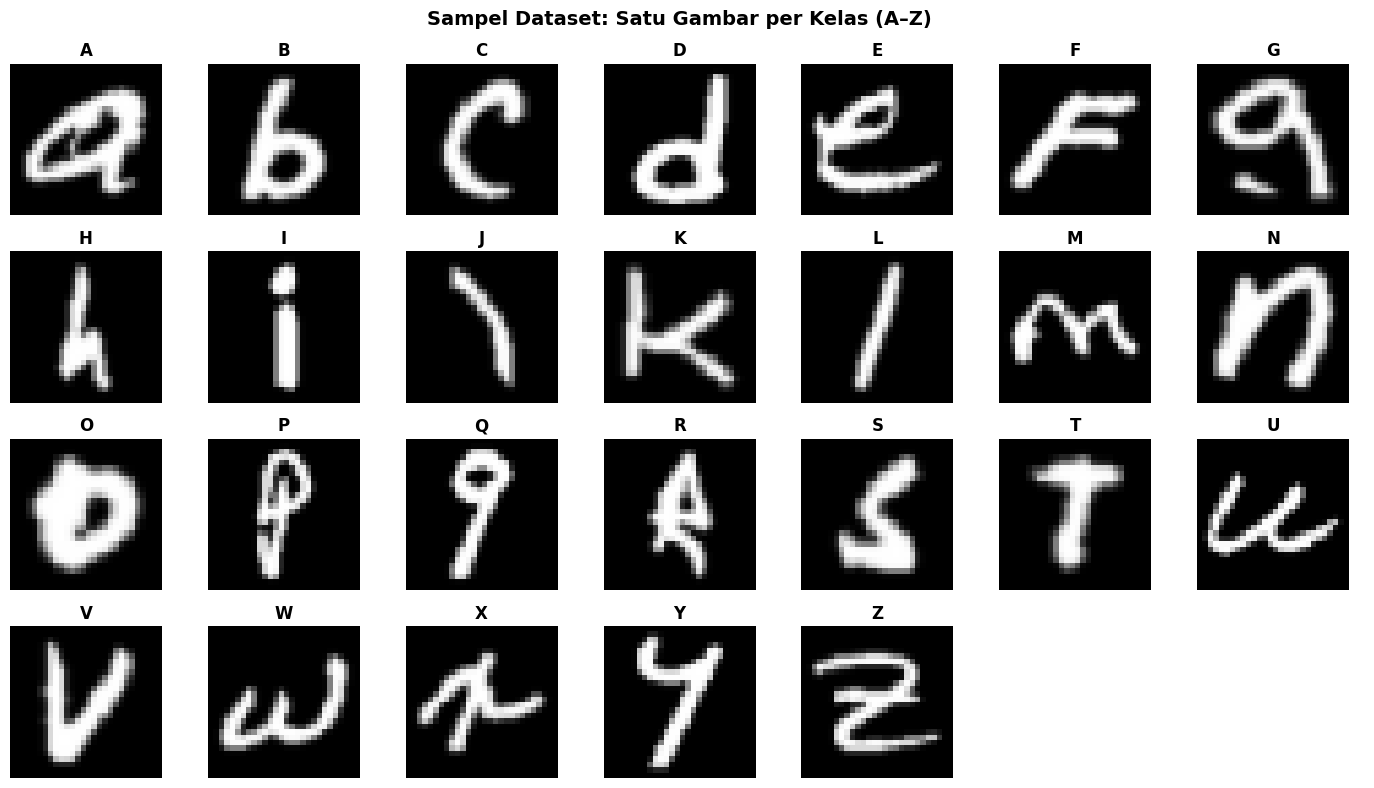

In [5]:
# ── Visualisasi Sampel Dataset ──────────────────────────────────
fig, axes = plt.subplots(4, 7, figsize=(14, 8))
axes = axes.flatten()

for class_idx in range(NUM_CLASSES):
    sample_idx = np.where(y == class_idx)[0][0]
    img = np.transpose(X[sample_idx].reshape(28, 28))
    axes[class_idx].imshow(img, cmap='gray')
    axes[class_idx].set_title(chr(class_idx + 97).upper(), fontsize=12, fontweight='bold')
    axes[class_idx].axis('off')

for i in range(NUM_CLASSES, len(axes)):
    axes[i].axis('off')

plt.suptitle('Sampel Dataset: Satu Gambar per Kelas (A–Z)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sampel_dataset.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 4. Feature Extraction — HOG (Histogram of Oriented Gradients)

HOG mengekstrak informasi bentuk dan tepi dari gambar berdasarkan arah gradien piksel.

| Parameter | Nilai Dipakai | Default |
|---|---|---|
| `orientations` | **8** | 9 |
| `pixels_per_cell` | **(4, 4)** | (8, 8) |
| `cells_per_block` | **(2, 2)** | (3, 3) |
| `block_norm` | **L2** | L2-Hys |

In [6]:
# ── Parameter HOG ───────────────────────────────────────────────
HOG_PARAMS = dict(
    orientations    = 8,
    pixels_per_cell = (4, 4),
    cells_per_block = (2, 2),
    block_norm      = 'L2'
)

def extract_hog_features(images, **hog_params):
    features = []
    for img in images:
        feat = hog(img.reshape(28, 28), **hog_params)
        features.append(feat)
    return np.array(features)

print('Mengekstrak fitur HOG dari 2600 gambar...')
X_hog = extract_hog_features(X, **HOG_PARAMS)
print(f'✅ Ekstraksi selesai!')
print(f'   Dimensi fitur HOG : {X_hog.shape[1]} fitur per gambar')
print(f'   X_hog shape       : {X_hog.shape}')

Mengekstrak fitur HOG dari 2600 gambar...
✅ Ekstraksi selesai!
   Dimensi fitur HOG : 1152 fitur per gambar
   X_hog shape       : (2600, 1152)


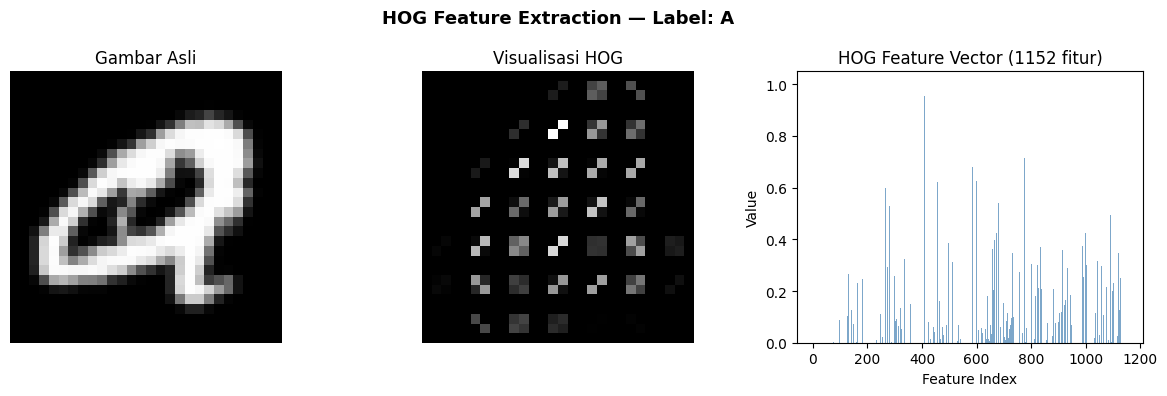

In [7]:
# ── Visualisasi HOG ─────────────────────────────────────────────
sample_feat, sample_hog_img = hog(
    X[0].reshape(28, 28), visualize=True, **HOG_PARAMS
)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(np.transpose(X[0].reshape(28, 28)), cmap='gray')
axes[0].set_title('Gambar Asli', fontsize=12)
axes[0].axis('off')

axes[1].imshow(sample_hog_img, cmap='gray')
axes[1].set_title('Visualisasi HOG', fontsize=12)
axes[1].axis('off')

axes[2].bar(range(len(sample_feat)), sample_feat, color='steelblue', alpha=0.7)
axes[2].set_title(f'HOG Feature Vector ({len(sample_feat)} fitur)', fontsize=12)
axes[2].set_xlabel('Feature Index')
axes[2].set_ylabel('Value')

plt.suptitle(f'HOG Feature Extraction — Label: {chr(y[0]+97).upper()}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Split Dataset — 80% Train / 20% Test

Dataset dibagi secara **stratified** agar proporsi kelas tetap seimbang di kedua set.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_hog, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y
)

print('✅ Dataset berhasil dibagi!')
print(f'   Training set : {X_train.shape[0]} sampel ({X_train.shape[0]/len(X_hog)*100:.0f}%)')
print(f'   Testing set  : {X_test.shape[0]} sampel ({X_test.shape[0]/len(X_hog)*100:.0f}%)')

✅ Dataset berhasil dibagi!
   Training set : 2080 sampel (80%)
   Testing set  : 520 sampel (20%)


---
## 6. Klasifikasi — SVM dengan Grid Search

**Support Vector Machine (SVM)** digunakan untuk klasifikasi.
**Grid Search** digunakan untuk mencari kombinasi parameter terbaik.

| Parameter | Nilai yang Dicoba |
|---|---|
| `kernel` | linear, rbf, poly |
| `C` (Regularization) | 0.1, 1, 10 |
| `gamma` | scale, auto |

In [9]:
param_grid = {
    'C'      : [0.1, 1, 10],
    'kernel' : ['linear', 'rbf', 'poly'],
    'gamma'  : ['scale', 'auto']
}

grid_search = GridSearchCV(
    SVC(), param_grid,
    cv      = 5,
    n_jobs  = -1,
    verbose = 1,
    scoring = 'accuracy'
)

print('Menjalankan Grid Search...')
grid_search.fit(X_train, y_train)

best_svm = grid_search.best_estimator_

print(f'\n✅ Grid Search selesai!')
print(f'   Parameter terbaik : {grid_search.best_params_}')
print(f'   Skor CV terbaik   : {grid_search.best_score_:.4f}')

Menjalankan Grid Search...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

✅ Grid Search selesai!
   Parameter terbaik : {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
   Skor CV terbaik   : 0.8173


---
## 7. Evaluasi — Data Train (80%)

In [10]:
y_train_pred = best_svm.predict(X_train)

print('=' * 55)
print('         EVALUASI PADA DATA TRAIN (80%)')
print('=' * 55)
print(f'Accuracy  : {accuracy_score(y_train, y_train_pred):.4f}')
print(f'Precision : {precision_score(y_train, y_train_pred, average="weighted", zero_division=0):.4f}')
print(f'Recall    : {recall_score(y_train, y_train_pred, average="weighted", zero_division=0):.4f}')
print(f'F1-Score  : {f1_score(y_train, y_train_pred, average="weighted", zero_division=0):.4f}')
print()
print(classification_report(
    y_train, y_train_pred,
    target_names=[chr(i+97).upper() for i in range(26)],
    zero_division=0
))

         EVALUASI PADA DATA TRAIN (80%)
Accuracy  : 0.9995
Precision : 0.9995
Recall    : 0.9995
F1-Score  : 0.9995

              precision    recall  f1-score   support

           A       1.00      1.00      1.00        80
           B       1.00      1.00      1.00        80
           C       1.00      1.00      1.00        80
           D       1.00      1.00      1.00        80
           E       1.00      1.00      1.00        80
           F       1.00      1.00      1.00        80
           G       1.00      1.00      1.00        80
           H       1.00      1.00      1.00        80
           I       1.00      0.99      0.99        80
           J       1.00      1.00      1.00        80
           K       1.00      1.00      1.00        80
           L       0.99      1.00      0.99        80
           M       1.00      1.00      1.00        80
           N       1.00      1.00      1.00        80
           O       1.00      1.00      1.00        80
           P      

---
## 8. Evaluasi — Data Test (20%)

In [11]:
y_test_pred = best_svm.predict(X_test)

print('=' * 55)
print('         EVALUASI PADA DATA TEST (20%)')
print('=' * 55)
print(f'Accuracy  : {accuracy_score(y_test, y_test_pred):.4f}')
print(f'Precision : {precision_score(y_test, y_test_pred, average="weighted", zero_division=0):.4f}')
print(f'Recall    : {recall_score(y_test, y_test_pred, average="weighted", zero_division=0):.4f}')
print(f'F1-Score  : {f1_score(y_test, y_test_pred, average="weighted", zero_division=0):.4f}')
print()
print(classification_report(
    y_test, y_test_pred,
    target_names=[chr(i+97).upper() for i in range(26)],
    zero_division=0
))

         EVALUASI PADA DATA TEST (20%)
Accuracy  : 0.8423
Precision : 0.8492
Recall    : 0.8423
F1-Score  : 0.8436

              precision    recall  f1-score   support

           A       0.70      0.80      0.74        20
           B       0.89      0.80      0.84        20
           C       0.95      1.00      0.98        20
           D       0.89      0.80      0.84        20
           E       0.89      0.85      0.87        20
           F       0.89      0.85      0.87        20
           G       0.61      0.70      0.65        20
           H       1.00      0.85      0.92        20
           I       0.55      0.55      0.55        20
           J       0.86      0.95      0.90        20
           K       0.85      0.85      0.85        20
           L       0.45      0.50      0.48        20
           M       0.95      0.95      0.95        20
           N       0.87      1.00      0.93        20
           O       0.79      0.95      0.86        20
           P       

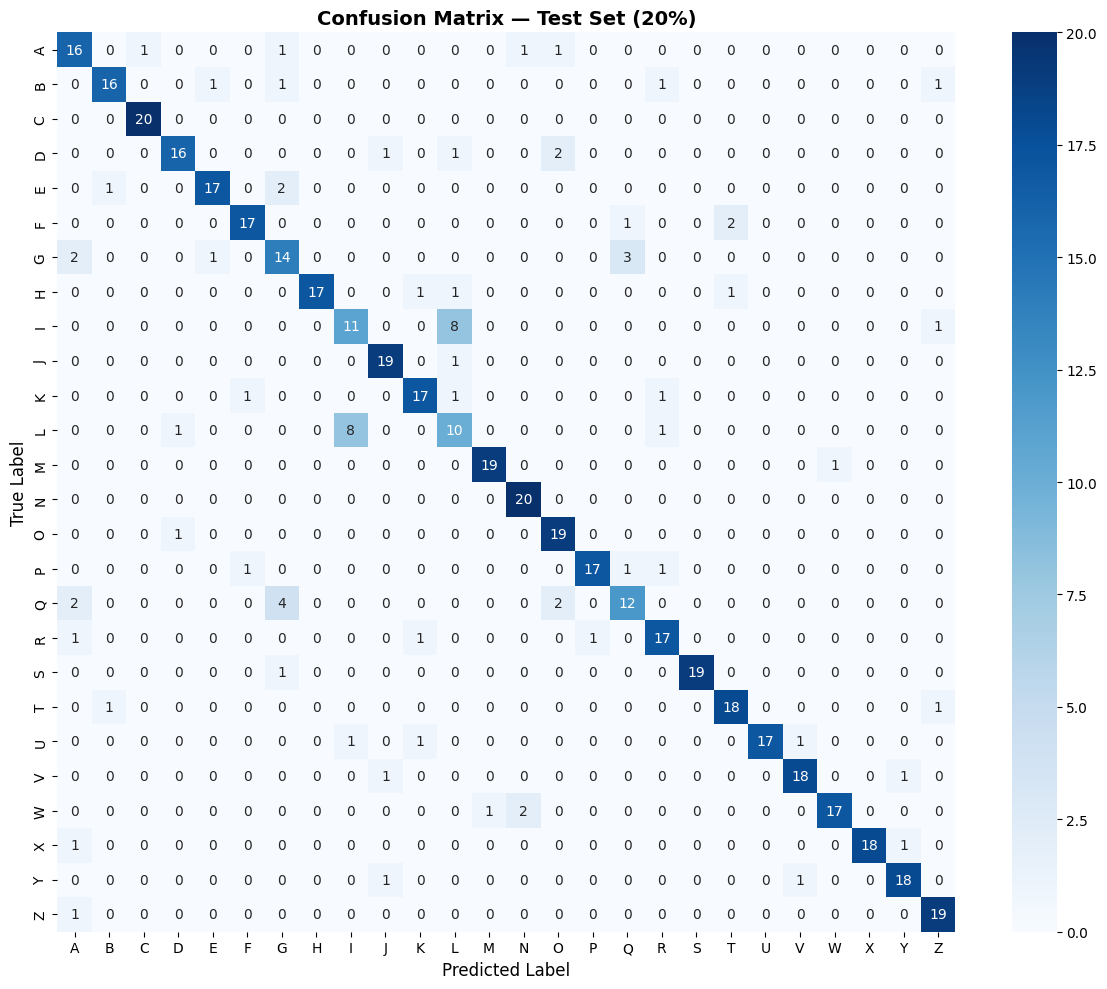

In [12]:
# ── Confusion Matrix Test Set ───────────────────────────────────
cm_test = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_test, annot=True, fmt='d', cmap='Blues',
    xticklabels=[chr(i+97).upper() for i in range(26)],
    yticklabels=[chr(i+97).upper() for i in range(26)]
)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix — Test Set (20%)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Evaluasi — Leave-One-Out Cross Validation (LOOCV)

**LOOCV** adalah metode evaluasi di mana:
- Setiap iterasi, **1 sampel** dipakai sebagai data test
- Sisanya (**2599 sampel**) dipakai sebagai data train
- Proses ini diulang **2600 kali** (satu kali per sampel)
- Hasil akhir adalah rata-rata dari semua iterasi



In [13]:
print('Parameter SVM untuk LOOCV :', grid_search.best_params_)
print(f'Jumlah iterasi            : {len(X_hog)} kali')
print('\nMenjalankan LOOCV...')

loocv_model = SVC(**grid_search.best_params_)
loo         = LeaveOneOut()

y_loo_pred = cross_val_predict(
    loocv_model, X_hog, y,
    cv     = loo,
    n_jobs = -1,
    verbose= 0
)

print('✅ LOOCV selesai!')

Parameter SVM untuk LOOCV : {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Jumlah iterasi            : 2600 kali

Menjalankan LOOCV...
✅ LOOCV selesai!


In [14]:
print('=' * 55)
print('      HASIL EVALUASI LOOCV (2600 sampel)')
print('=' * 55)
print(f'Accuracy  : {accuracy_score(y, y_loo_pred):.4f}')
print(f'Precision : {precision_score(y, y_loo_pred, average="weighted", zero_division=0):.4f}')
print(f'Recall    : {recall_score(y, y_loo_pred, average="weighted", zero_division=0):.4f}')
print(f'F1-Score  : {f1_score(y, y_loo_pred, average="weighted", zero_division=0):.4f}')
print()
print(classification_report(
    y, y_loo_pred,
    target_names=[chr(i+97).upper() for i in range(26)],
    zero_division=0
))

      HASIL EVALUASI LOOCV (2600 sampel)
Accuracy  : 0.8442
Precision : 0.8456
Recall    : 0.8442
F1-Score  : 0.8443

              precision    recall  f1-score   support

           A       0.71      0.79      0.75       100
           B       0.85      0.90      0.87       100
           C       0.87      0.94      0.90       100
           D       0.91      0.88      0.89       100
           E       0.89      0.85      0.87       100
           F       0.93      0.89      0.91       100
           G       0.69      0.67      0.68       100
           H       0.86      0.89      0.88       100
           I       0.59      0.61      0.60       100
           J       0.82      0.85      0.83       100
           K       0.85      0.88      0.87       100
           L       0.62      0.59      0.61       100
           M       0.94      0.89      0.91       100
           N       0.84      0.86      0.85       100
           O       0.86      0.94      0.90       100
           P     

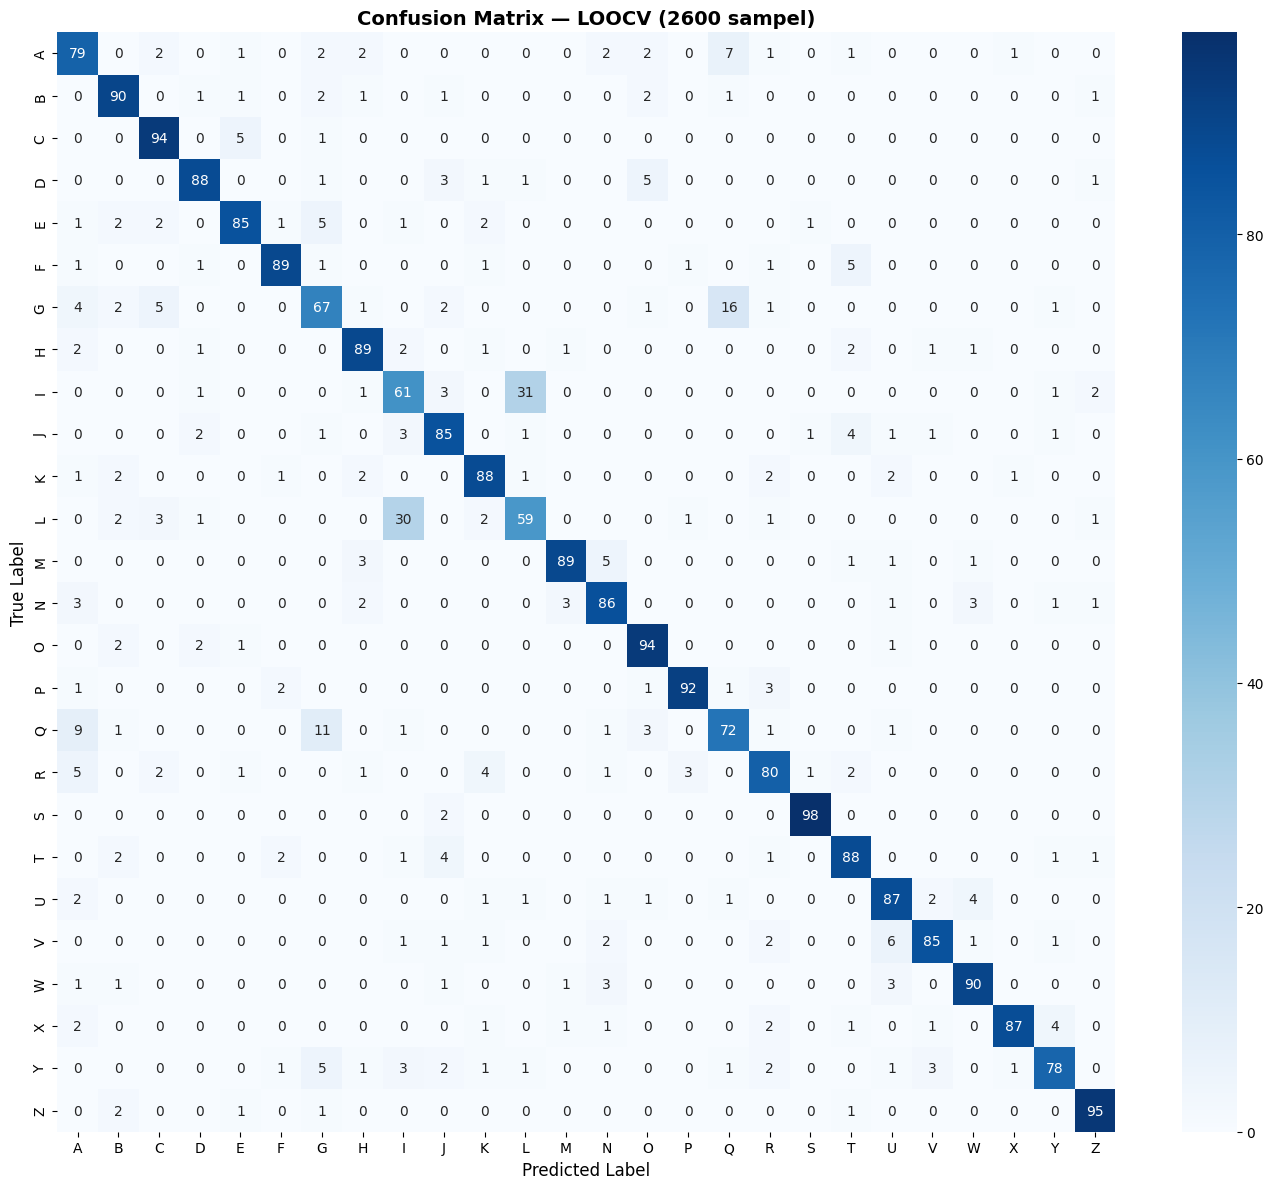

In [15]:
# ── Confusion Matrix LOOCV ──────────────────────────────────────
cm_loo = confusion_matrix(y, y_loo_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(
    cm_loo, annot=True, fmt='d', cmap='Blues',
    xticklabels=[chr(i+97).upper() for i in range(26)],
    yticklabels=[chr(i+97).upper() for i in range(26)]
)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix — LOOCV (2600 sampel)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. Visualisasi Prediksi Test Set

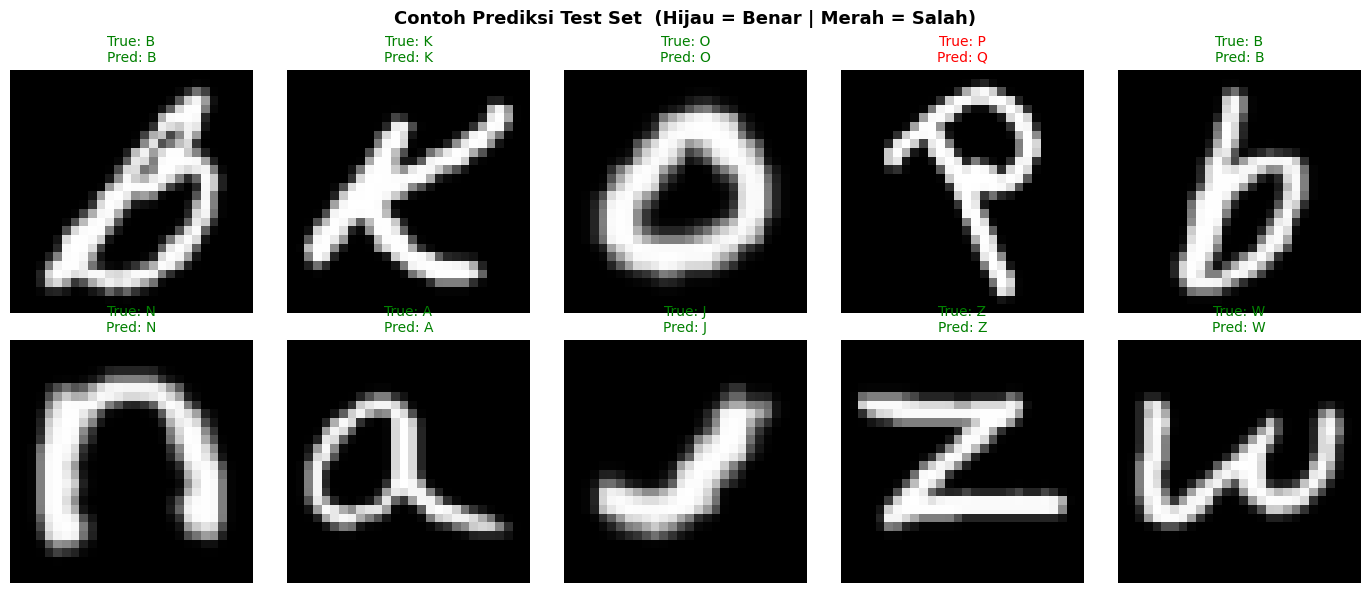

In [16]:
import random

# Ambil gambar asli untuk test set
X_raw_train, X_raw_test, _, _ = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

indices = random.sample(range(len(X_raw_test)), 10)
plt.figure(figsize=(14, 6))

for i, idx in enumerate(indices):
    img        = np.transpose(X_raw_test[idx].reshape(28, 28))
    true_label = y_test[idx]
    pred_label = y_test_pred[idx]
    color      = 'green' if true_label == pred_label else 'red'

    plt.subplot(2, 5, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(
        f'True: {chr(true_label+97).upper()}\nPred: {chr(pred_label+97).upper()}',
        color=color, fontsize=10
    )
    plt.axis('off')

plt.suptitle('Contoh Prediksi Test Set  (Hijau = Benar | Merah = Salah)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()